In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
df=pd.read_csv("Social_Network_Ads.csv")
df=pd.get_dummies(df,drop_first=True)

In [3]:
indep = df[['Age','EstimatedSalary','Gender_Male']]
dep = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size=0.3, random_state=0)

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

gsv = GridSearchCV(SVC(), param_grid, cv=5)
gsv.fit(X_train, y_train)
gsv.best_params_

{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

              precision    recall  f1-score   support

           0       0.77      0.86      0.81        79
           1       0.66      0.51      0.58        41

    accuracy                           0.74       120
   macro avg       0.71      0.69      0.69       120
weighted avg       0.73      0.74      0.73       120



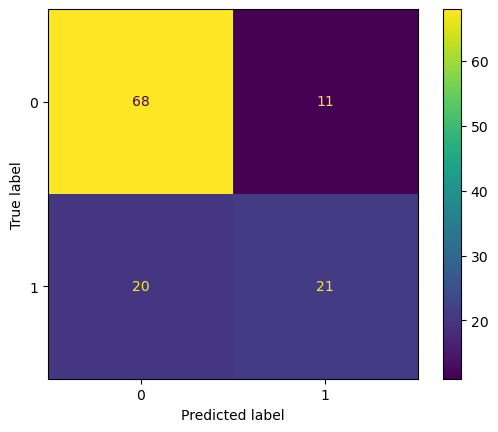

In [6]:
svm = SVC(**gsv.best_params_)   
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)


print(classification_report(y_test, y_pred))

cf = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cf).plot()